## Setup + raw data load (shared across all three DAG sections)

In [2]:
# Cell 1: Setup + raw data load (shared across all three DAG sections)

import subprocess, sys
for pkg in ["dowhy", "econml", "pandas", "numpy", "matplotlib", "seaborn"]:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg], check=False)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dowhy import CausalModel
from econml.dml import CausalForestDML
import os

pd.set_option("display.max_columns", None)
save_dir = r"C:\Users\Disha Sharma\Desktop\Paper_1\RQ2"
os.makedirs(save_dir, exist_ok=True)

df = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\AAA.csv")
df.shape

In [4]:
# Cell 2: Shared encoding maps (reused across all three DAG sections)

final_result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
education_map = {
    'No Formal quals': 0, 'Lower Than A Level': 1, 'A Level or Equivalent': 2,
    'HE Qualification': 3, 'Post Graduate Qualification': 4
}
imd_map = {
    '0-10%': 0, '10-20%': 1, '20-30%': 2, '30-40%': 3, '40-50%': 4,
    '50-60%': 5, '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9
}
age_band_map = {'0-35': 0, '35-55': 1, '55<=': 2}

# Section A — DAG 1 (Demographics vs final_result)

In [7]:
# Cell 3: DAG 1 preprocessing -- demographics only

demographics = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
                'disability', 'studied_credits', 'num_of_prev_attempts']

df_dag1 = df[demographics + ['final_result']].copy()

df_dag1['imd_band'] = df_dag1['imd_band'].replace('10-20', '10-20%')
df_dag1['imd_band'] = df_dag1['imd_band'].fillna(df_dag1['imd_band'].mode()[0])

df_dag1['final_result'] = df_dag1['final_result'].map(final_result_map)
df_dag1['highest_education'] = df_dag1['highest_education'].map(education_map)
df_dag1['imd_band'] = df_dag1['imd_band'].map(imd_map)
df_dag1['age_band'] = df_dag1['age_band'].map(age_band_map)
df_dag1['gender'] = df_dag1['gender'].map({'M': 0, 'F': 1})
df_dag1['disability'] = df_dag1['disability'].map({'N': 0, 'Y': 1})
df_dag1['region'] = df_dag1['region'].astype('category').cat.codes

print(df_dag1.isnull().sum().sum())
df_dag1.shape

0


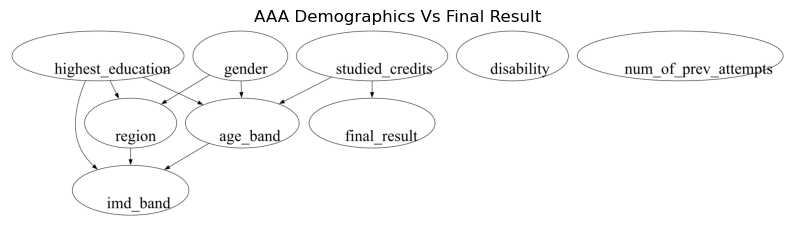

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

dag_img = mpimg.imread(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\AAA_DAG1_studentinfo_vs_finalresult.png") 

plt.figure(figsize=(10, 10))
plt.imshow(dag_img)
plt.axis('off')
plt.title("AAA Demographics Vs Final Result")
plt.show()

In [13]:
# Cell 4: DAG 1 -- ATE, single treatment (studied_credits, root)

model = CausalModel(data=df_dag1, treatment='studied_credits', outcome='final_result', common_causes=[])
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
estimate = model.estimate_effect(identified_estimand, method_name="backdoor.linear_regression", confidence_intervals=True)
ci = estimate.get_confidence_intervals()
print(f"studied_credits: ATE = {estimate.value:.4f}, CI = [{ci[0][0]:.4f}, {ci[0][1]:.4f}]")

studied_credits: ATE = -0.0038, CI = [-0.0051, -0.0025]


# Section B — DAG 2 (Assessments vs final_result)

In [16]:
# Cell 5: DAG 2 preprocessing -- assessments only

score_cols = ['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score']
df_dag2 = df[score_cols + ['final_result']].copy()

df_dag2[score_cols] = df_dag2[score_cols].fillna(-1)
for col in score_cols:
    df_dag2[col] = pd.qcut(df_dag2[col], q=4, labels=False, duplicates='drop')
df_dag2['final_result'] = df_dag2['final_result'].map(final_result_map)

print(df_dag2.isnull().sum().sum())
df_dag2.shape

0


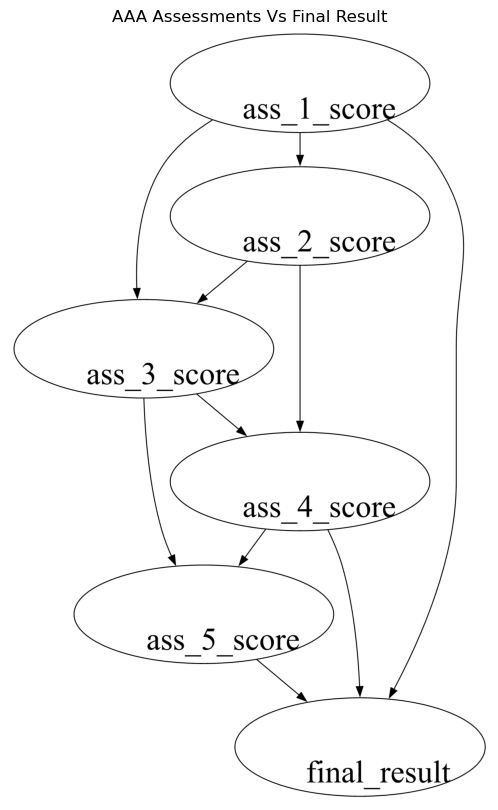

In [25]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

dag_img = mpimg.imread(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\AAA_DAG2_assessments_vs_finalresult.png") 

plt.figure(figsize=(10, 10))
plt.imshow(dag_img)
plt.axis('off')
plt.title("AAA Assessments Vs Final Result")
plt.show()

In [18]:
# Cell 6: DAG 2 -- ATE loop, 5 treatments

treatments_dag2 = {
    'ass_1_score': [],
    'ass_2_score': ['ass_1_score'],
    'ass_3_score': ['ass_1_score', 'ass_2_score'],
    'ass_4_score': ['ass_2_score', 'ass_3_score'],
    'ass_5_score': ['ass_3_score', 'ass_4_score'],
}

results_dag2 = []
for treatment, common_causes in treatments_dag2.items():
    model = CausalModel(data=df_dag2, treatment=treatment, outcome='final_result', common_causes=common_causes)
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(identified_estimand, method_name="backdoor.linear_regression", confidence_intervals=True)
    ci = estimate.get_confidence_intervals()
    results_dag2.append({'treatment': treatment, 'adjustment_set': ', '.join(common_causes) if common_causes else '(none -- root)',
                          'ate': estimate.value, 'ci_lower': ci[0][0], 'ci_upper': ci[0][1]})
    print(f"{treatment}: ATE = {estimate.value:.4f}, CI = [{ci[0][0]:.4f}, {ci[0][1]:.4f}]")

results_dag2_df = pd.DataFrame(results_dag2)
results_dag2_df

ass_1_score: ATE = 0.2617, CI = [0.2112, 0.3122]
ass_2_score: ATE = 0.3271, CI = [0.2696, 0.3846]
ass_3_score: ATE = 0.3937, CI = [0.3301, 0.4572]
ass_4_score: ATE = 0.4274, CI = [0.3643, 0.4904]
ass_5_score: ATE = 0.3190, CI = [0.2575, 0.3804]


,treatment,adjustment_set,ate,ci_lower,ci_upper
0,ass_1_score,(none -- root),0.261698,0.211158,0.312237
1,ass_2_score,ass_1_score,0.327107,0.269639,0.384575
2,ass_3_score,"ass_1_score, ass_2_score",0.393657,0.330072,0.457242
3,ass_4_score,"ass_2_score, ass_3_score",0.427357,0.364289,0.490424
4,ass_5_score,"ass_3_score, ass_4_score",0.318975,0.257512,0.380438


# Section C — DAG 3 (Individual clicks vs final_result)

In [21]:
# Cell 7: DAG 3 preprocessing -- individual clicks, pulled fresh from raw df

click_cols = [c for c in df.columns if c.startswith('clicks_')]
df_dag3 = df[click_cols + ['final_result']].copy()

df_dag3[click_cols] = df_dag3[click_cols].fillna(0)
for col in click_cols:
    df_dag3[col] = pd.qcut(df_dag3[col], q=4, labels=False, duplicates='drop')
df_dag3['final_result'] = df_dag3['final_result'].map(final_result_map)

print(df_dag3.isnull().sum().sum())
df_dag3.shape

0


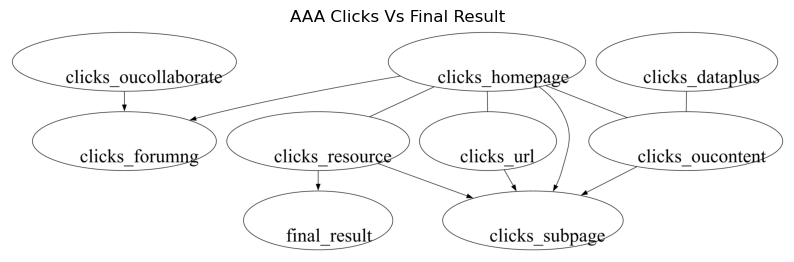

In [27]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

dag_img = mpimg.imread(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\AAA_DAG3_clicks_vs_finalresult.png") 

plt.figure(figsize=(10, 10))
plt.imshow(dag_img)
plt.axis('off')
plt.title("AAA Clicks Vs Final Result")
plt.show()

In [23]:
# Cell 8: DAG 3 -- ATE, single treatment (clicks_resource, root)

model = CausalModel(data=df_dag3, treatment='clicks_resource', outcome='final_result', common_causes=[])
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
estimate = model.estimate_effect(identified_estimand, method_name="backdoor.linear_regression", confidence_intervals=True)
ci = estimate.get_confidence_intervals()
print(f"clicks_resource: ATE = {estimate.value:.4f}, CI = [{ci[0][0]:.4f}, {ci[0][1]:.4f}]")

clicks_resource: ATE = 0.2887, CI = [0.2396, 0.3377]


## Refutation Testing -- 3-DAG Split (7 treatments)

Placebo treatment refuter and random common cause refuter applied to all 7 treatments
across DAG 1 (studied_credits), DAG 2 (5 assessments), and DAG 3 (clicks_resource).

Same logic as the combined-DAG pass: placebo should collapse the effect toward zero
(confirms the ATE isn't a method artifact), random common cause should leave the
effect roughly unchanged (confirms robustness to unobserved confounding).

In [30]:
# Cell 9: Refutation -- DAG 1 (studied_credits)

model = CausalModel(data=df_dag1, treatment='studied_credits', outcome='final_result', common_causes=[])
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
estimate = model.estimate_effect(identified_estimand, method_name="backdoor.linear_regression")

placebo = model.refute_estimate(identified_estimand, estimate, method_name="placebo_treatment_refuter", placebo_type="permute")
random_cause = model.refute_estimate(identified_estimand, estimate, method_name="random_common_cause")

print(f"studied_credits: original ATE = {estimate.value:.4f}")
print(f"  Placebo -> new effect ≈ {placebo.new_effect:.4f} (should be ≈ 0)")
print(f"  Random common cause -> new effect ≈ {random_cause.new_effect:.4f} (should ≈ original)")

studied_credits: original ATE = -0.0038
  Placebo -> new effect ≈ -0.0000 (should be ≈ 0)
  Random common cause -> new effect ≈ -0.0038 (should ≈ original)


In [32]:
# Cell 10: Refutation -- DAG 2 (5 assessment treatments)

refutation_dag2 = []

for treatment, common_causes in treatments_dag2.items():
    model = CausalModel(data=df_dag2, treatment=treatment, outcome='final_result', common_causes=common_causes)
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(identified_estimand, method_name="backdoor.linear_regression")
    
    placebo = model.refute_estimate(identified_estimand, estimate, method_name="placebo_treatment_refuter", placebo_type="permute")
    random_cause = model.refute_estimate(identified_estimand, estimate, method_name="random_common_cause")
    
    refutation_dag2.append({
        'treatment': treatment, 'original_ate': estimate.value,
        'placebo_new_effect': placebo.new_effect,
        'random_cause_new_effect': random_cause.new_effect
    })
    
    print(f"{treatment}: original ATE = {estimate.value:.4f}")
    print(f"  Placebo -> new effect ≈ {placebo.new_effect:.4f} (should be ≈ 0)")
    print(f"  Random common cause -> new effect ≈ {random_cause.new_effect:.4f} (should ≈ original)")
    print()

refutation_dag2_df = pd.DataFrame(refutation_dag2)
refutation_dag2_df

ass_1_score: original ATE = 0.2617
  Placebo -> new effect ≈ 0.0014 (should be ≈ 0)
  Random common cause -> new effect ≈ 0.2617 (should ≈ original)

ass_2_score: original ATE = 0.3271
  Placebo -> new effect ≈ 0.0012 (should be ≈ 0)
  Random common cause -> new effect ≈ 0.3271 (should ≈ original)

ass_3_score: original ATE = 0.3937
  Placebo -> new effect ≈ -0.0007 (should be ≈ 0)
  Random common cause -> new effect ≈ 0.3935 (should ≈ original)

ass_4_score: original ATE = 0.4274
  Placebo -> new effect ≈ 0.0023 (should be ≈ 0)
  Random common cause -> new effect ≈ 0.4272 (should ≈ original)

ass_5_score: original ATE = 0.3190
  Placebo -> new effect ≈ 0.0020 (should be ≈ 0)
  Random common cause -> new effect ≈ 0.3190 (should ≈ original)



,treatment,original_ate,placebo_new_effect,random_cause_new_effect
0,ass_1_score,0.261698,0.001431,0.261736
1,ass_2_score,0.327107,0.001150,0.327142
2,ass_3_score,0.393657,-0.000658,0.393482
3,ass_4_score,0.427357,0.002337,0.427206
4,ass_5_score,0.318975,0.002001,0.318978


In [34]:
# Cell 11: Refutation -- DAG 3 (clicks_resource)

model = CausalModel(data=df_dag3, treatment='clicks_resource', outcome='final_result', common_causes=[])
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
estimate = model.estimate_effect(identified_estimand, method_name="backdoor.linear_regression")

placebo = model.refute_estimate(identified_estimand, estimate, method_name="placebo_treatment_refuter", placebo_type="permute")
random_cause = model.refute_estimate(identified_estimand, estimate, method_name="random_common_cause")

print(f"clicks_resource: original ATE = {estimate.value:.4f}")
print(f"  Placebo -> new effect ≈ {placebo.new_effect:.4f} (should be ≈ 0)")
print(f"  Random common cause -> new effect ≈ {random_cause.new_effect:.4f} (should ≈ original)")

clicks_resource: original ATE = 0.2887
  Placebo -> new effect ≈ 0.0032 (should be ≈ 0)
  Random common cause -> new effect ≈ 0.2888 (should ≈ original)


## Heterogeneous Treatment Effect (CATE) Estimation -- 3-DAG Split (DAG 2: Assessments)

EconML CausalForestDML applied to DAG 2's 5 assessment treatments, using age_band and
imd_band as candidate heterogeneity moderators (same comparison as the combined-DAG pass).

studied_credits (DAG 1) and clicks_resource (DAG 3) are excluded from CATE -- both are
root nodes with no other DAG-connected variables in their respective domain-split
dataframes, so there is no meaningful confounder set (W) to condition on beyond the
moderator itself.

age_band and imd_band are pulled back in from the raw dataframe, since DAG 2's
dataframe (df_dag2) contains only assessment columns and final_result.

Point + confidence interval plots are used instead of boxplots for the same reason as
the combined-DAG pass: CausalForestDML's effect() returns one CATE value per moderator
bin, not a within-bin distribution, so a boxplot would misrepresent the output.

In [37]:
# Cell 12: Add age_band, imd_band back into DAG 2's dataframe for CATE

df_dag2_cate = df_dag2.copy()
df_dag2_cate['age_band'] = df['age_band'].map(age_band_map)

imd_temp = df['imd_band'].replace('10-20', '10-20%')
imd_temp = imd_temp.fillna(imd_temp.mode()[0])
df_dag2_cate['imd_band'] = imd_temp.map(imd_map)

print(df_dag2_cate[['age_band', 'imd_band']].isnull().sum())
df_dag2_cate.shape

age_band    0
imd_band    0
dtype: int64


In [39]:
# Cell 13: CATE summary -- DAG 2, age_band and imd_band as moderators, all 5 treatments

Y_dag2 = df_dag2_cate['final_result']
cate_summary_dag2 = []

for treatment, common_causes in treatments_dag2.items():
    T = df_dag2_cate[treatment]
    W_data = df_dag2_cate[common_causes] if common_causes else None
    
    for moderator in ['age_band', 'imd_band']:
        X = df_dag2_cate[[moderator]]
        est = CausalForestDML(random_state=42)
        est.fit(Y_dag2, T, X=X, W=W_data)
        cate = est.effect(X)
        
        cate_summary_dag2.append({
            'treatment': treatment, 'moderator': moderator,
            'cate_mean': cate.mean(), 'cate_min': cate.min(),
            'cate_max': cate.max(), 'cate_std': cate.std()
        })
    
    print(f"{treatment} done")

cate_summary_dag2_df = pd.DataFrame(cate_summary_dag2)
cate_summary_dag2_df

ass_1_score done
ass_2_score done
ass_3_score done
ass_4_score done
ass_5_score done


,treatment,moderator,cate_mean,cate_min,cate_max,cate_std
0,ass_1_score,age_band,0.260014,0.243895,0.359642,0.026922
1,ass_1_score,imd_band,0.270657,0.096627,0.494890,0.130270
2,ass_2_score,age_band,0.326068,0.245570,0.398181,0.075903
3,ass_2_score,imd_band,0.311429,0.113847,0.452585,0.125542
4,ass_3_score,age_band,0.353992,0.331462,0.562191,0.053423
5,ass_3_score,imd_band,0.341291,0.112797,0.574940,0.098806
6,ass_4_score,age_band,0.407322,0.269380,0.470353,0.063142
7,ass_4_score,imd_band,0.432440,0.319734,0.623938,0.074610
8,ass_5_score,age_band,0.217610,0.147744,0.280423,0.065728
9,ass_5_score,imd_band,0.233630,0.104445,0.473143,0.092572


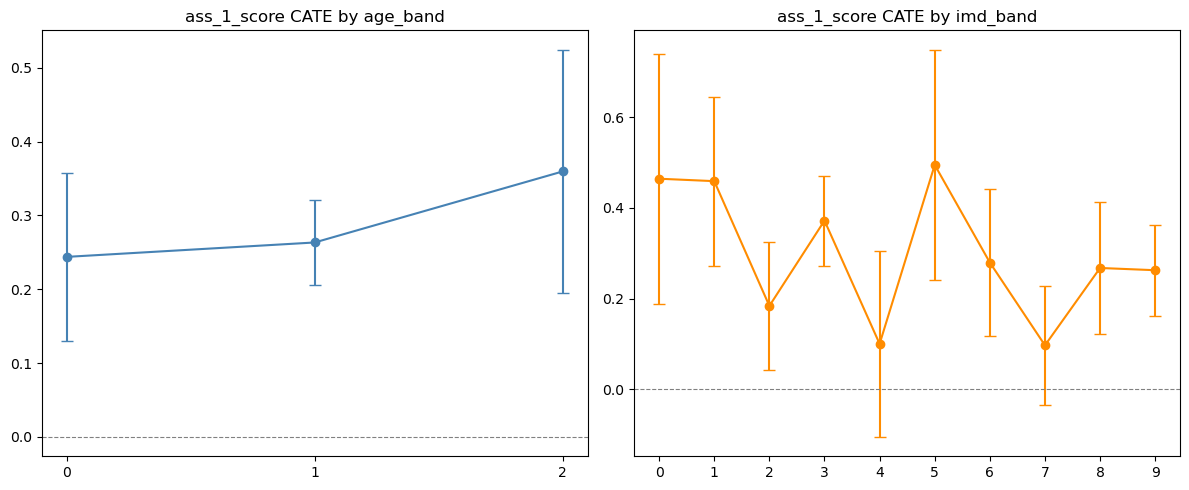

In [41]:
# Cell 14: CATE by moderator bin, with confidence intervals -- ass_1_score worked example
# (same point+CI approach settled on for the combined DAG -- no boxplot)

treatment = 'ass_1_score'
common_causes = treatments_dag2[treatment]
T = df_dag2_cate[treatment]
W_data = df_dag2_cate[common_causes] if common_causes else None

age_vals = sorted(df_dag2_cate['age_band'].unique())
imd_vals = sorted(df_dag2_cate['imd_band'].unique())

est_age = CausalForestDML(random_state=42)
est_age.fit(Y_dag2, T, X=df_dag2_cate[['age_band']], W=W_data)
X_age_bins = pd.DataFrame({'age_band': age_vals})
cate_age_bins = est_age.effect(X_age_bins)
lb_age, ub_age = est_age.effect_interval(X_age_bins, alpha=0.05)

est_imd = CausalForestDML(random_state=42)
est_imd.fit(Y_dag2, T, X=df_dag2_cate[['imd_band']], W=W_data)
X_imd_bins = pd.DataFrame({'imd_band': imd_vals})
cate_imd_bins = est_imd.effect(X_imd_bins)
lb_imd, ub_imd = est_imd.effect_interval(X_imd_bins, alpha=0.05)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].errorbar(age_vals, cate_age_bins, yerr=[cate_age_bins - lb_age, ub_age - cate_age_bins], fmt='o-', capsize=4, color='steelblue')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title(f'{treatment} CATE by age_band')
axes[0].set_xticks(age_vals)

axes[1].errorbar(imd_vals, cate_imd_bins, yerr=[cate_imd_bins - lb_imd, ub_imd - cate_imd_bins], fmt='o-', capsize=4, color='darkorange')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title(f'{treatment} CATE by imd_band')
axes[1].set_xticks(imd_vals)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"AAA_DAG2_CATE_{treatment}.png"), dpi=150, bbox_inches='tight')
plt.show()

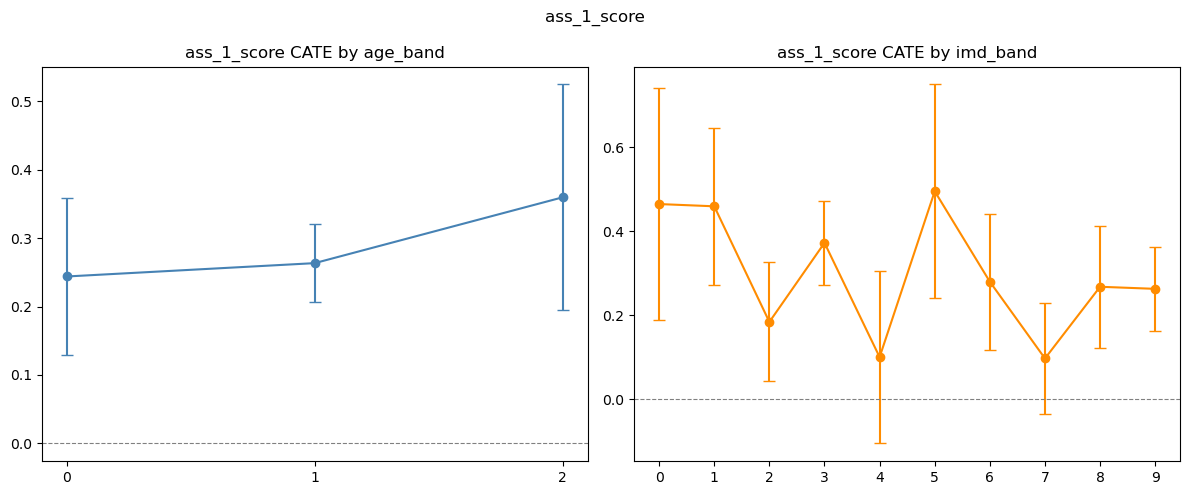

ass_1_score saved



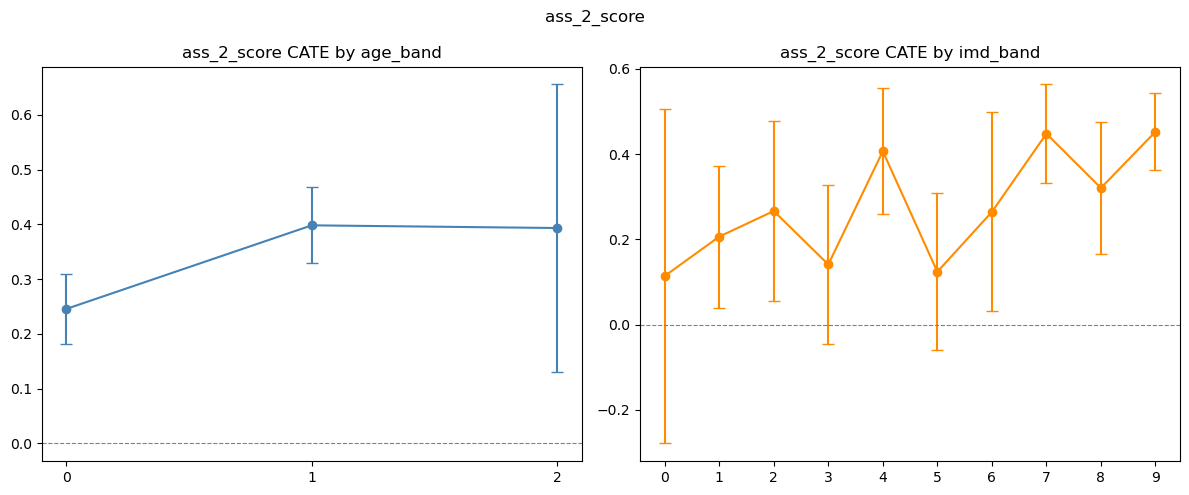

ass_2_score saved



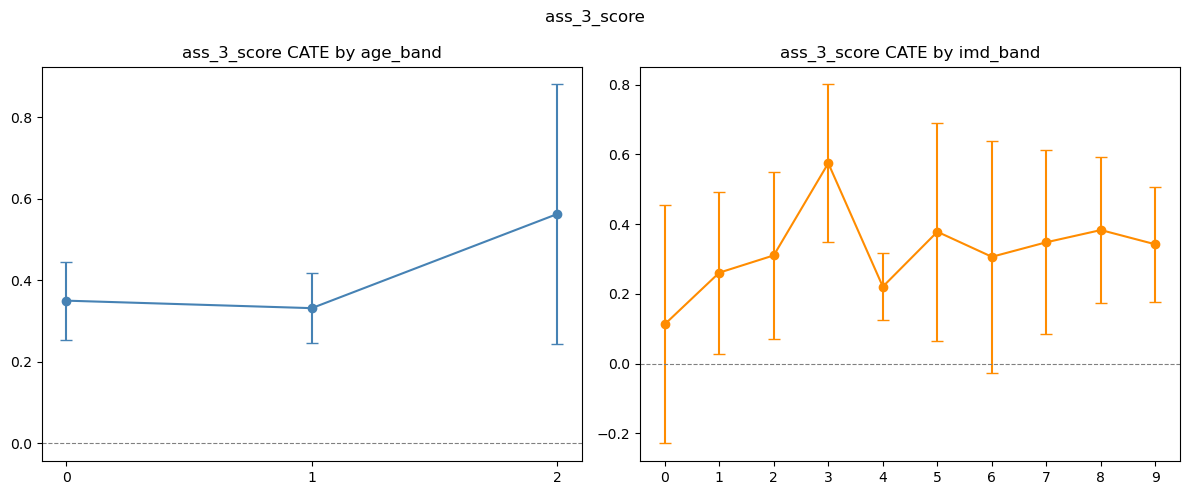

ass_3_score saved



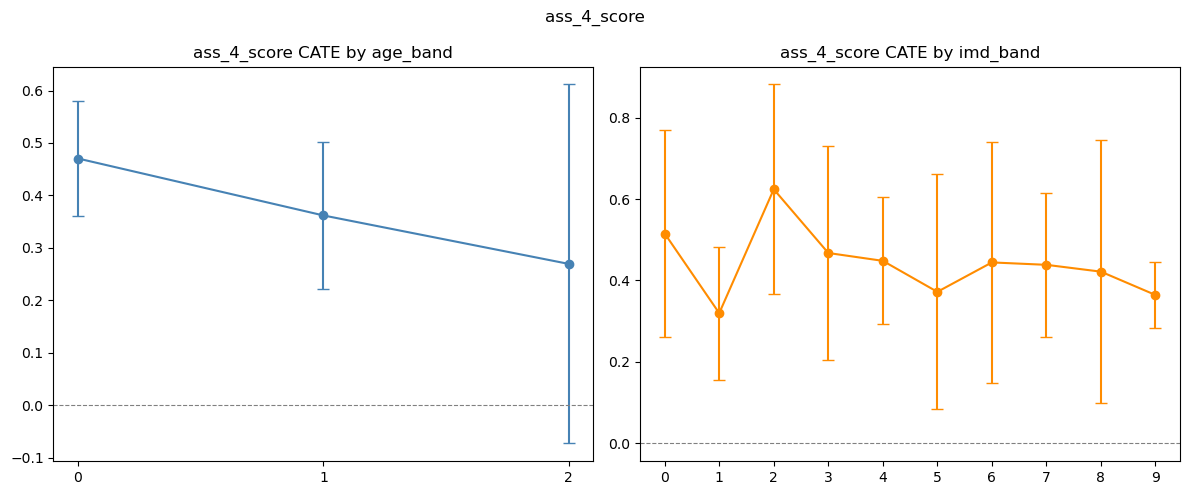

ass_4_score saved



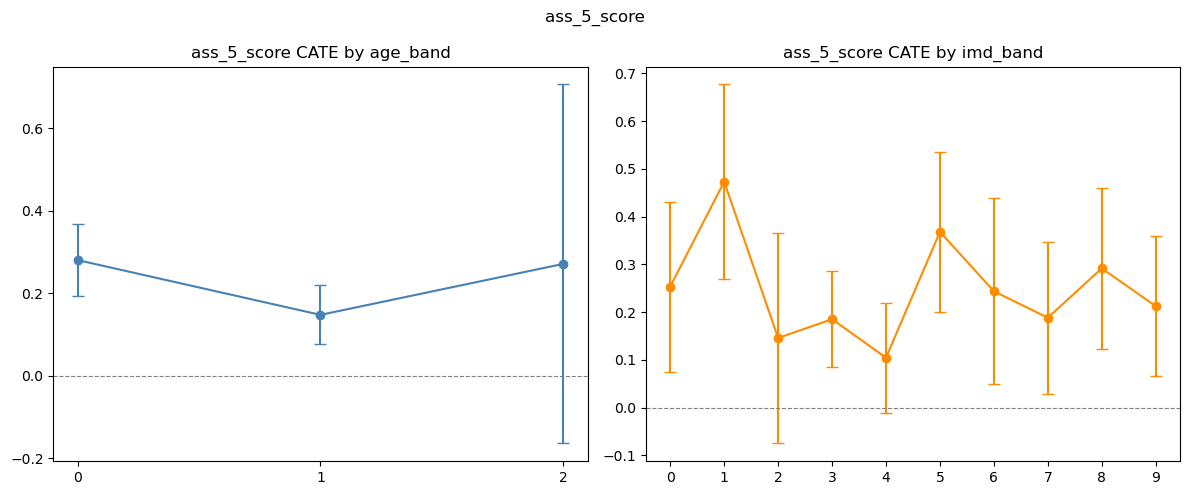

ass_5_score saved



In [43]:
# Cell 15: CATE by moderator bin, with confidence intervals -- looped across all 5 DAG 2 treatments

age_vals = sorted(df_dag2_cate['age_band'].unique())
imd_vals = sorted(df_dag2_cate['imd_band'].unique())

for treatment, common_causes in treatments_dag2.items():
    T = df_dag2_cate[treatment]
    W_data = df_dag2_cate[common_causes] if common_causes else None
    
    est_age = CausalForestDML(random_state=42)
    est_age.fit(Y_dag2, T, X=df_dag2_cate[['age_band']], W=W_data)
    X_age_bins = pd.DataFrame({'age_band': age_vals})
    cate_age_bins = est_age.effect(X_age_bins)
    lb_age, ub_age = est_age.effect_interval(X_age_bins, alpha=0.05)
    
    est_imd = CausalForestDML(random_state=42)
    est_imd.fit(Y_dag2, T, X=df_dag2_cate[['imd_band']], W=W_data)
    X_imd_bins = pd.DataFrame({'imd_band': imd_vals})
    cate_imd_bins = est_imd.effect(X_imd_bins)
    lb_imd, ub_imd = est_imd.effect_interval(X_imd_bins, alpha=0.05)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].errorbar(age_vals, cate_age_bins, yerr=[cate_age_bins - lb_age, ub_age - cate_age_bins], fmt='o-', capsize=4, color='steelblue')
    axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[0].set_title(f'{treatment} CATE by age_band')
    axes[0].set_xticks(age_vals)
    
    axes[1].errorbar(imd_vals, cate_imd_bins, yerr=[cate_imd_bins - lb_imd, ub_imd - cate_imd_bins], fmt='o-', capsize=4, color='darkorange')
    axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[1].set_title(f'{treatment} CATE by imd_band')
    axes[1].set_xticks(imd_vals)
    
    plt.suptitle(treatment)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"AAA_DAG2_CATE_{treatment}.png"), dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"{treatment} saved\n")

## Visual Representations -- 3-DAG Split 
Same two formats as the combined-DAG notebook: an ATE heatmap (all 7 treatments across
the three domain-split DAGs) and DAG structures with nodes colored/sized by ATE
magnitude. Since DAG 1/2/3 are three separate graphs (not one), the DAG-overlay is done
per-DAG rather than as a single combined figure.

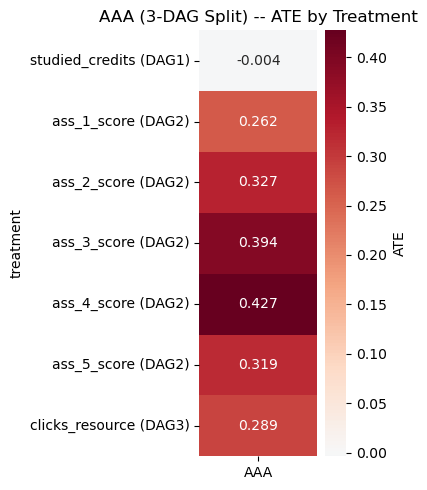

In [46]:
# Cell 16: ATE heatmap -- all 7 treatments across DAG 1/2/3 (AAA only, extensible to BBB-GGG)

all_results_3dag = pd.DataFrame([
    {'treatment': 'studied_credits (DAG1)', 'ate': -0.003800},
    {'treatment': 'ass_1_score (DAG2)', 'ate': 0.261698},
    {'treatment': 'ass_2_score (DAG2)', 'ate': 0.327107},
    {'treatment': 'ass_3_score (DAG2)', 'ate': 0.393657},
    {'treatment': 'ass_4_score (DAG2)', 'ate': 0.427357},
    {'treatment': 'ass_5_score (DAG2)', 'ate': 0.318975},
    {'treatment': 'clicks_resource (DAG3)', 'ate': 0.288700},
])

heatmap_data_3dag = all_results_3dag.set_index('treatment')[['ate']].rename(columns={'ate': 'AAA'})

plt.figure(figsize=(4, 5))
sns.heatmap(heatmap_data_3dag, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'ATE'})
plt.title('AAA (3-DAG Split) -- ATE by Treatment')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "AAA_3DAGSplit_ATE_heatmap.png"), dpi=150, bbox_inches='tight')
plt.show()

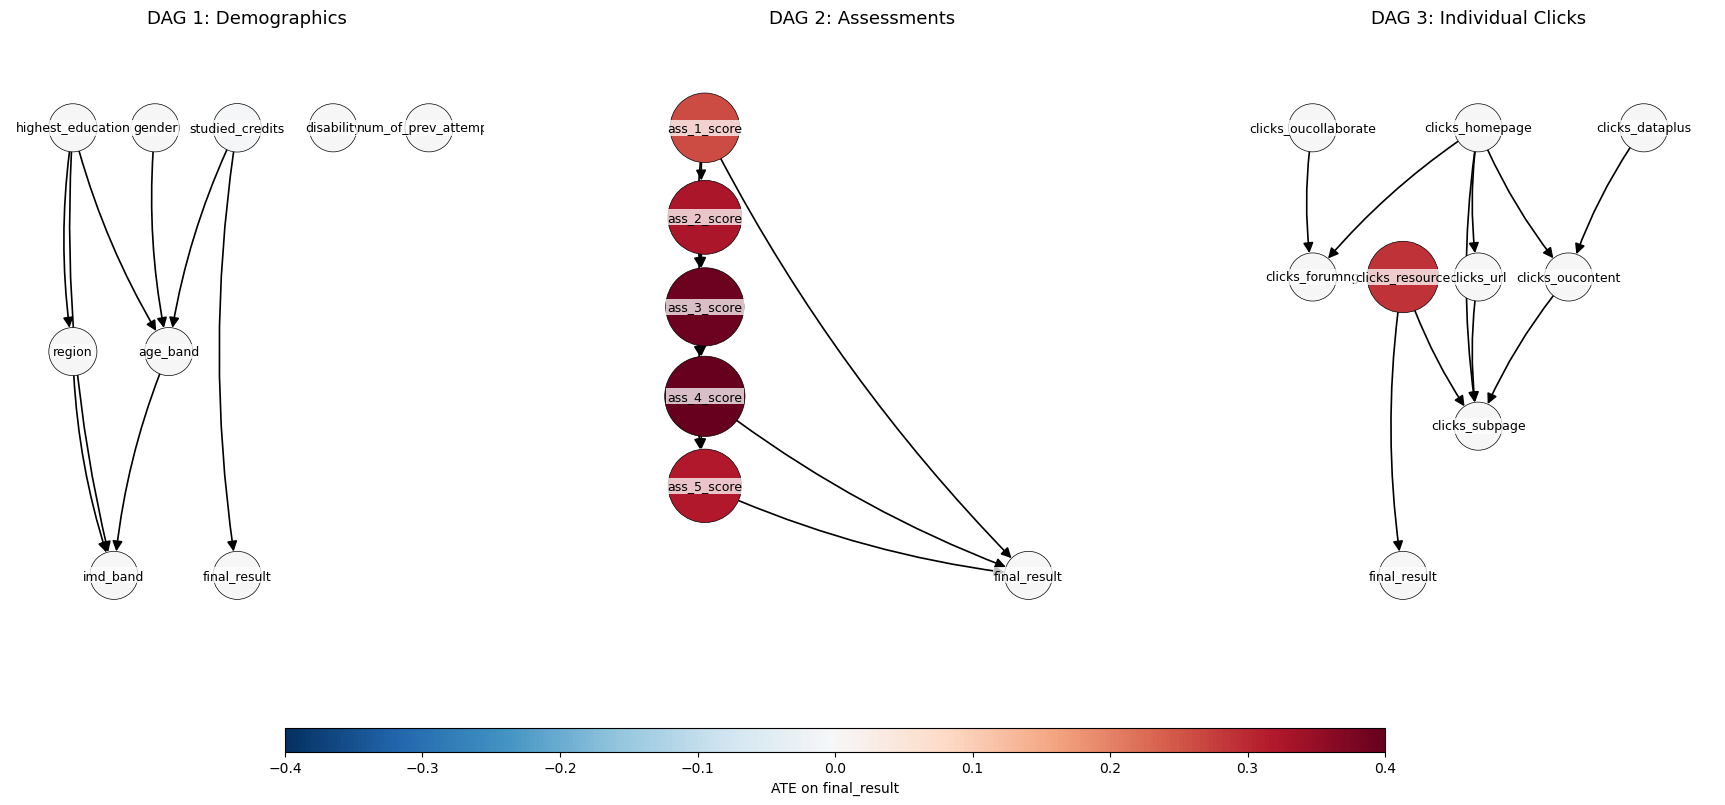

In [50]:
# Cell 17 (rebuilt): DAG structures with ATE overlay -- manual layout, publishable version

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

def draw_dag(ax, G, pos, ate_lookup, title):
    colors = [ate_lookup.get(n, 0) for n in G.nodes()]
    sizes = [1200 + 5000 * abs(ate_lookup.get(n, 0)) for n in G.nodes()]
    nodes = nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=sizes,
                                     cmap='RdBu_r', vmin=-0.4, vmax=0.4, edgecolors='black', linewidths=0.5)
    nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=15, width=1.2,
                            connectionstyle='arc3,rad=0.08', node_size=sizes)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=9,
                             bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=1))
    ax.set_title(title, fontsize=13)
    ax.axis('off')
    ax.margins(0.15)
    return nodes

# --- DAG 1: Demographics ---
G1 = nx.DiGraph()
G1.add_edges_from([
    ('gender', 'age_band'), ('highest_education', 'age_band'),
    ('highest_education', 'region'), ('highest_education', 'imd_band'),
    ('studied_credits', 'age_band'), ('studied_credits', 'final_result'),
    ('region', 'imd_band'), ('age_band', 'imd_band'),
])
G1.add_nodes_from(['disability', 'num_of_prev_attempts'])
pos1 = {
    'highest_education': (0, 3), 'gender': (1.2, 3), 'studied_credits': (2.4, 3),
    'disability': (3.8, 3), 'num_of_prev_attempts': (5.2, 3),
    'region': (0, 2), 'age_band': (1.4, 2),
    'imd_band': (0.6, 1), 'final_result': (2.4, 1),
}
ate1 = {'studied_credits': -0.0038}
n1 = draw_dag(axes[0], G1, pos1, ate1, 'DAG 1: Demographics')

# --- DAG 2: Assessments ---
G2 = nx.DiGraph()
G2.add_edges_from([
    ('ass_1_score', 'ass_2_score'), ('ass_1_score', 'ass_3_score'), ('ass_1_score', 'final_result'),
    ('ass_2_score', 'ass_3_score'), ('ass_2_score', 'ass_4_score'),
    ('ass_3_score', 'ass_4_score'), ('ass_3_score', 'ass_5_score'),
    ('ass_4_score', 'ass_5_score'), ('ass_4_score', 'final_result'),
    ('ass_5_score', 'final_result'),
])
pos2 = {
    'ass_1_score': (0.7, 4), 'ass_2_score': (0.7, 3), 'ass_3_score': (0.7, 2),
    'ass_4_score': (0.7, 1), 'ass_5_score': (0.7, 0), 'final_result': (2, -1),
}
ate2 = dict(zip(results_dag2_df['treatment'], results_dag2_df['ate']))
n2 = draw_dag(axes[1], G2, pos2, ate2, 'DAG 2: Assessments')

# --- DAG 3: Individual Clicks ---
G3 = nx.DiGraph()
G3.add_edges_from([
    ('clicks_oucollaborate', 'clicks_forumng'), ('clicks_homepage', 'clicks_forumng'),
    ('clicks_homepage', 'clicks_url'), ('clicks_homepage', 'clicks_subpage'),
    ('clicks_homepage', 'clicks_oucontent'), ('clicks_url', 'clicks_subpage'),
    ('clicks_oucontent', 'clicks_subpage'), ('clicks_dataplus', 'clicks_oucontent'),
    ('clicks_resource', 'clicks_subpage'), ('clicks_resource', 'final_result'),
])
pos3 = {
    'clicks_oucollaborate': (0, 3), 'clicks_homepage': (2.2, 3), 'clicks_dataplus': (4.4, 3),
    'clicks_forumng': (0, 2), 'clicks_resource': (1.2, 2), 'clicks_url': (2.2, 2), 'clicks_oucontent': (3.4, 2),
    'clicks_subpage': (2.2, 1), 'final_result': (1.2, 0),
}
ate3 = {'clicks_resource': 0.2887}
n3 = draw_dag(axes[2], G3, pos3, ate3, 'DAG 3: Individual Clicks')

cbar_ax = fig.add_axes([0.25, 0.02, 0.5, 0.03])
fig.colorbar(n2, cax=cbar_ax, orientation='horizontal', label='ATE on final_result')

plt.subplots_adjust(bottom=0.12, top=0.92, wspace=0.3)
plt.savefig(os.path.join(save_dir, "AAA_3DAGSplit_DAG_with_ATE.png"), dpi=200, bbox_inches='tight')
plt.show()